In [80]:
import sys, os
from omegaconf import OmegaConf
import torch
import numpy as np
import pandas as pd
import glob
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm import tqdm
sys.path.append("/home/jgershon/git/cleo/reinforced_mpnn")
sys.path.append("/projects/ml/itopt/policy_mpnn/software/pipelines/pipelines/blocks")
from policy_utils import PolicyMPNN, alphabet
import random
import secrets

def get_pairwise_dists(all_seqs):
        
        all_dists = []
        for i in range(len(all_seqs)):
            for j in range(len(all_seqs)):
                if i < j:
                    dist = 1 - (sum([1 for a, b in zip(all_seqs[i], all_seqs[j]) if a != b]) / len(all_seqs[i]))
                    all_dists.append(dist)

        return all_dists

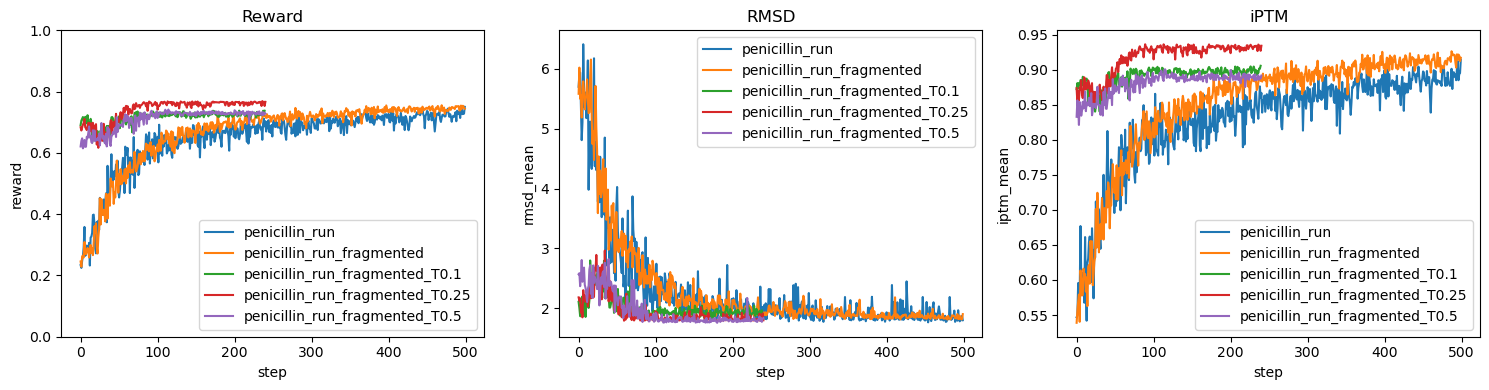

In [81]:
path = "/home/jgershon/projects/itopt/policy_mpnn/test_runs/test_penicillin_train_metrics.csv"

path = "/home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg/penicillin_vanilla_pg_train_metrics.csv"
df = pd.read_csv(path)

base_path = "/home/jgershon/projects/itopt/policy_mpnn"

fig, ax = plt.subplots(1,3,figsize=(15, 4))

def plot_metrics(folder, label, base_path=base_path, fig=fig, ax=ax):
    
    path = os.path.join(base_path, folder, "*train_metrics.csv")
    train_metrics_path = glob.glob(path)[0]
    df = pd.read_csv(train_metrics_path)


    sns.lineplot(data=df, x="step", y="reward", label=label, ax=ax[0])
    ax[0].set_title("Reward")
    ax[0].set_ylim(0, 1)

    sns.lineplot(data=df, x="step", y="rmsd_mean", label=label, ax=ax[1])
    ax[1].set_title("RMSD")

    sns.lineplot(data=df, x="step", y="iptm_mean", label=label, ax=ax[2])
    ax[2].set_title("iPTM")

to_plot = [
    ("penicillin_vanilla_pg","penicillin_run",),
    ("penicillin_vanilla_pg_fragmented","penicillin_run_fragmented",),
    ("penicillin_vanilla_pg_fragmented_T0.1", "penicillin_run_fragmented_T0.1",),
    ("penicillin_vanilla_pg_fragmented_T0.25", "penicillin_run_fragmented_T0.25",),
    ("penicillin_vanilla_pg_fragmented_T0.5", "penicillin_run_fragmented_T0.5",),
    # ("heme_vanilla_pg","heme_run",),
    # ("heme_vanilla_pg_fragmented","heme_run_fragmented",),

]

for p in to_plot:
    plot_metrics(p[0], p[1], base_path=base_path, fig=fig, ax=ax)

plt.tight_layout()


Text(0.5, 1.0, 'Sequence Similarity | temp=1.0')

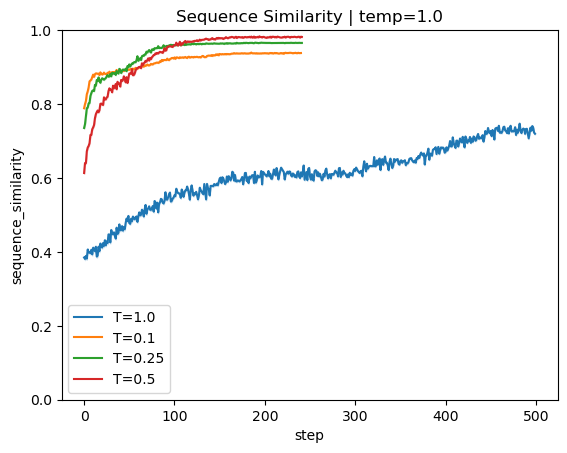

In [88]:

def get_stepwise_diversity(folder, base_path=base_path):

    search_path = os.path.join(base_path,folder,"pipeline_output/*/*.csv")
    files = glob.glob(search_path)

    datas = {
        "step": [],
        "sequence_similarity": [],
    }

    for f in files:
        tmp = pd.read_csv(f)
        all_seqs = tmp["sequence"].tolist()
        all_dists = get_pairwise_dists(all_seqs)
        datas["step"].extend([int(f.split("/")[-2].split("_")[-1])] * len(all_dists))
        datas["sequence_similarity"].extend(all_dists)

    return pd.DataFrame(datas)

df_T1 = get_stepwise_diversity("penicillin_vanilla_pg_fragmented")
df_T01 = get_stepwise_diversity("penicillin_vanilla_pg_fragmented_T0.1")
df_T025 = get_stepwise_diversity("penicillin_vanilla_pg_fragmented_T0.25")
df_T05 = get_stepwise_diversity("penicillin_vanilla_pg_fragmented_T0.5")


sns.lineplot(data=df_T1, x="step", y="sequence_similarity", label="T=1.0",)
sns.lineplot(data=df_T01, x="step", y="sequence_similarity", label="T=0.1")
sns.lineplot(data=df_T025, x="step", y="sequence_similarity", label="T=0.25")
sns.lineplot(data=df_T05, x="step", y="sequence_similarity", label="T=0.5")
plt.ylim(0, 1)

plt.title("Sequence Similarity | temp=1.0")


In [55]:
500*16

8000

In [18]:
# for penicillin enzyme
fragment_bounds = [(0,29),(30,66),(67,102),(103,130),(131,157)]


# for heme enzyme
# fragment_bounds = [(0,24),(25,49),(50,74),(75,99),(100,124),(125,149),(150,174),(175,199),(200,224),(225,251)]


In [ ]:
fragment_bounds = [(0,24),(25,49),(50,74),(75,99),(100,124),(125,149),(150,184)]


In [ ]:
import biotite.structure.io as strucio

sys.path.append("/home/jgershon")
from pdb_util import get_rmsd


motif_residues = [50, 69, 72, 121, 229, 232]

motif_atoms = {
    "A50": ["CB", "CG", "OD1", "OD2"],
    "A69": ["CB", "CG", "ND1", "CD2", "CE1", "NE2"],
    "A72": ["CB", "CSG"],
    "A121": ["CB", "CG", "ND1", "CD2", "CE1", "NE2"],
    "A229": ["CB", "CG", "ND1", "CD2", "CE1", "NE2"],
    "A232": ["CB", "CG", "ND1", "CD1", "CD2", "CE1", "CE2", "CZ"],
}

In [ ]:
# setting up elliot benchmark
ref_path = "/home/jgershon/from/elliot/elliot_design.pdb"
des_path = "/home/jgershon/from/elliot/elliot_af3.cif"

ref_atoms = strucio.load_structure(ref_path)
des_atoms = strucio.load_structure(des_path)


# for reference
ref_atoms.add_annotation("is_motif", np.dtype(bool))
ref_atoms.set_annotation("is_motif", np.full(len(ref_atoms), False))

# set atoms in the motif to True 
for resi in motif_atoms:
    chain = resi[0]
    idx = int(resi[1:])
    chain_and_idx_mask = (ref_atoms.res_id == idx) & (ref_atoms.chain_id == chain)
    atoms = motif_atoms[resi]
    mask = chain_and_idx_mask & np.isin(ref_atoms.atom_name, atoms)
    ref_atoms.is_motif[mask] = True

# copy annotation to is_motif_atom
ref_atoms.add_annotation("is_motif_atom", np.dtype(bool))
ref_atoms.set_annotation("is_motif_atom", ref_atoms.is_motif.copy())



# for design
des_atoms.add_annotation("is_motif", np.dtype(bool))
des_atoms.set_annotation("is_motif", np.full(len(des_atoms), False))

# set atoms in the motif to True 
for resi in motif_atoms:
    chain = resi[0]
    idx = int(resi[1:])
    chain_and_idx_mask = (des_atoms.res_id == idx) & (des_atoms.chain_id == chain)
    atoms = motif_atoms[resi]
    mask = chain_and_idx_mask & np.isin(des_atoms.atom_name, atoms)
    des_atoms.is_motif[mask] = True

# copy annotation to is_motif_atom
des_atoms.add_annotation("is_motif_atom", np.dtype(bool))
des_atoms.set_annotation("is_motif_atom", des_atoms.is_motif.copy())


In [ ]:
ref_motif_atoms = ref_atoms[ref_atoms.is_motif_atom]
des_motif_atoms = des_atoms[des_atoms.is_motif_atom]

In [ ]:
des_atoms[(des_atoms.chain_id == "C")].atom_name

array(['ZN', 'CHA', 'CHB', 'CHC', 'CHD', 'NA', 'C1A', 'C2A', 'C3A', 'C4A',
       'CMA', 'CAA', 'CBA', 'CGA', 'O1A', 'O2A', 'NB', 'C1B', 'C2B',
       'C3B', 'C4B', 'CMB', 'CAB', 'CBB', 'NC', 'C1C', 'C2C', 'C3C',
       'C4C', 'CMC', 'CAC', 'CBC', 'ND', 'C1D', 'C2D', 'C3D', 'C4D',
       'CMD', 'CAD', 'CBD', 'CGD', 'O1D', 'O2D'], dtype='<U6')

In [ ]:
ref_atoms[(ref_atoms.chain_id == "D")].atom_name

array(['C1A', 'NA', 'C4A', 'CHB', 'C1B', 'NB', 'C4B', 'CHC', 'C1C', 'C2C',
       'CMC', 'C3C', 'CAC', 'CBC', 'C4C', 'CHD', 'C1D', 'ND', 'C4D',
       'CHA', 'C3D', 'CAD', 'CBD', 'CGD', 'O1D', 'O2D', 'C2D', 'CMD',
       'ZN1', 'NC', 'C3B', 'CAB', 'CBB', 'C2B', 'CMB', 'C3A', 'CMA',
       'C2A', 'CAA', 'CBA', 'CGA', 'O1A', 'O2A'], dtype='<U6')

In [ ]:
for r in motif_residues:
    ref_sub = ref_atoms[(ref_atoms.chain_id == "A") & (ref_atoms.res_id == r)]
    des_sub = des_atoms[(des_atoms.chain_id == "A") & (des_atoms.res_id == r)]

    if r == 232:
        break

In [3]:
ref_path = "/projects/ml/itopt/policy_mpnn/benchmarks/protease/promising_24_hojae.cif"
des_path = "/home/jgershon/tmp/test/test_model.cif"
import biotite.structure.io as strucio

sys.path.append("/home/jgershon")
from pdb_util import get_rmsd


motif_residues = [50, 69, 72, 121, 229, 232]

motif_atoms = {
    "A40": ["CB", "CG", "ND2", "OD1"],
    "A43": ["CB", "CG", "ND2", "OD1"],
    "A44": ["O"],
    "A45": ["CG", "CD2", "ND1", "CE1", "NE2"],
    "A60": ["CB", "CG", "OD1", "OD2"],
    "A65": ["CG", "ND2", "OD1"],
    "A100": ["CB","SG"],
    "B7": ["N"],
    "B8": ["N"],
}

ref_atoms = strucio.load_structure(ref_path)
des_atoms = strucio.load_structure(des_path)


/home/jgershon/.conda/envs/newlatent/lib/python3.11/site-packages/biotite/structure/io/pdbx/convert.py:430: UserWarning: Attribute 'auth_seq_id' not found within 'atom_site' category. The fallback attribute 'label_seq_id' will be used instead
  warnings.warn(
/home/jgershon/.conda/envs/newlatent/lib/python3.11/site-packages/biotite/structure/io/pdbx/convert.py:430: UserWarning: Attribute 'auth_comp_id' not found within 'atom_site' category. The fallback attribute 'label_comp_id' will be used instead
  warnings.warn(
/home/jgershon/.conda/envs/newlatent/lib/python3.11/site-packages/biotite/structure/io/pdbx/convert.py:430: UserWarning: Attribute 'auth_atom_id' not found within 'atom_site' category. The fallback attribute 'label_atom_id' will be used instead
  warnings.warn(


In [5]:
xyz_ca = ref_atoms[ref_atoms.atom_name == "CA"].coord

In [6]:
xyz_ca.shape

(193, 3)

In [35]:
chain = "A"
idx = 45

ref_atoms[(ref_atoms.chain_id == chain) & (ref_atoms.res_id == idx)].atom_name, des_atoms[(des_atoms.chain_id == chain) & (des_atoms.res_id == idx)].atom_name


(array(['N', 'CA', 'C', 'O', 'CB', 'CG', 'CD2', 'ND1', 'CE1', 'NE2'],
       dtype='<U6'),
 array(['N', 'CA', 'C', 'O', 'CB', 'CG', 'ND1', 'CD2', 'CE1', 'NE2'],
       dtype='<U6'))

In [69]:
seqs = glob.glob("/home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0420/af3/outputs/seq_00*/*.cif")

for s in seqs:
    print(f"load {s}")

load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0420/af3/outputs/seq_0006/seq_0006_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0420/af3/outputs/seq_0043/seq_0043_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0420/af3/outputs/seq_0034/seq_0034_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0420/af3/outputs/seq_0049/seq_0049_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0420/af3/outputs/seq_0015/seq_0015_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0420/af3/outputs/seq_0062/seq_0062_model.cif
load /home/jgershon/projects